Train Accuracy: 0.7588
Test Accuracy: 0.7550
Accuracy Gap (Train - Test): 0.0038
Train AUC: 0.6856
Test AUC: 0.5685
AUC Gap (Train - Test): 0.1171

Classification Report (Test):
              precision    recall  f1-score   support

  Non-Severe       1.00      0.18      0.31        60
      Severe       0.74      1.00      0.85       140

    accuracy                           0.76       200
   macro avg       0.87      0.59      0.58       200
weighted avg       0.82      0.76      0.69       200



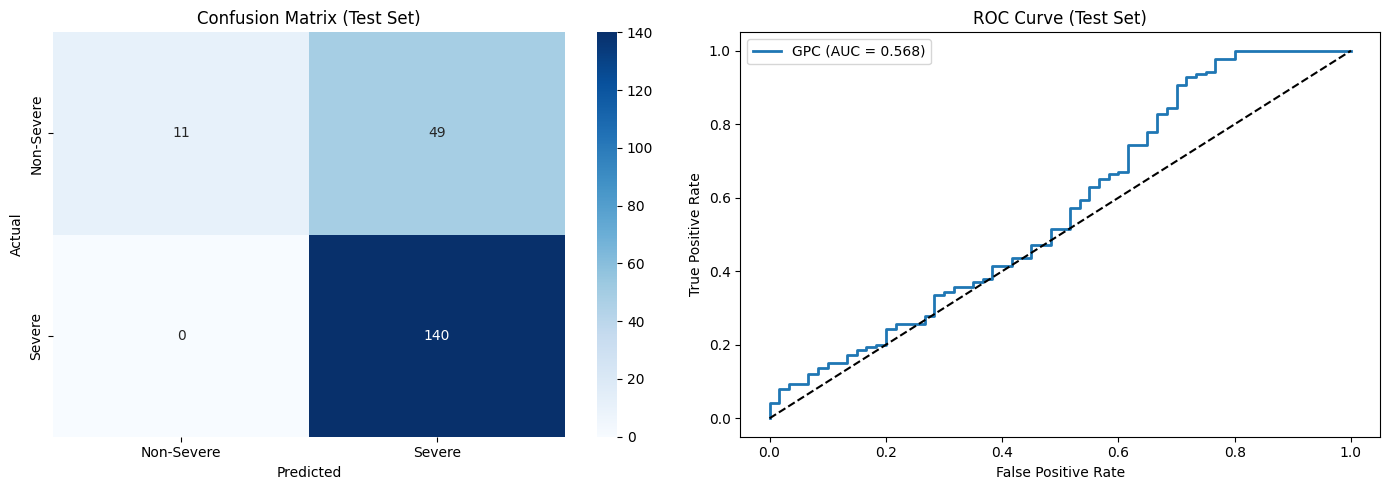

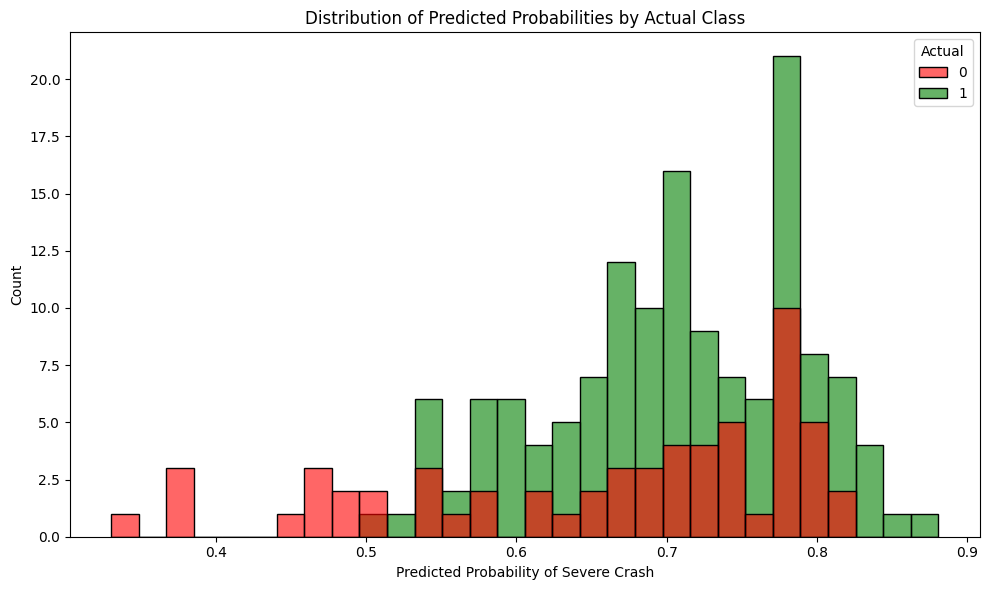


Optimized Kernel: 1.11**2 * RBF(length_scale=6.22) + WhiteKernel(noise_level=0.000973)


In [3]:
import subprocess
import sys
try:
    from sklearn.gaussian_process import GaussianProcessClassifier
    from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.gaussian_process import GaussianProcessClassifier
    from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
drop_cols = ['Quarter', 'State', 'Quarter_Date', 'State_Encoded']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
state_dummies = [c for c in df.columns if c.startswith('State_')]
df.drop(columns=state_dummies, inplace=True)
df = df.select_dtypes(include=[np.number])
df.dropna(inplace=True)
if 'Severe_Crash' not in df.columns:
    if 'Severe_Crash' in df.columns.str.lower():
        df = df.rename(columns={c: 'Severe_Crash' for c in df.columns if c.lower() == 'severe_crash'})
    else:
        df['Severe_Crash'] = (df['Total_Casualties'] > df['Total_Casualties'].median()).astype(int)
target = 'Severe_Crash'
X = df.drop(columns=[target, 'High_Casualty'] if 'High_Casualty' in df.columns else [target])
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
kernel = 1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e1))
gpc = GaussianProcessClassifier(kernel=kernel, optimizer='fmin_l_bfgs_b', n_restarts_optimizer=5, max_iter_predict=200, warm_start=True)
gpc.fit(X_train_scaled, y_train)
train_pred = gpc.predict(X_train_scaled)
test_pred = gpc.predict(X_test_scaled)
train_proba = gpc.predict_proba(X_train_scaled)[:, 1]
test_proba = gpc.predict_proba(X_test_scaled)[:, 1]
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, test_proba)
gap_acc = train_acc - test_acc
gap_auc = train_auc - test_auc
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Accuracy Gap (Train - Test): {gap_acc:.4f}")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"AUC Gap (Train - Test): {gap_auc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, target_names=['Non-Severe', 'Severe']))
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Severe', 'Severe'], yticklabels=['Non-Severe', 'Severe'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.plot(fpr, tpr, label=f'GPC (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig('gpc_results.png', dpi=150)
plt.show()
plt.figure(figsize=(10, 6))
y_pred_prob_df = pd.DataFrame({'Actual': y_test, 'Predicted Probability': test_proba})
sns.histplot(data=y_pred_prob_df, x='Predicted Probability', hue='Actual', bins=30, alpha=0.6, palette=['red', 'green'])
plt.xlabel('Predicted Probability of Severe Crash')
plt.ylabel('Count')
plt.title('Distribution of Predicted Probabilities by Actual Class')
plt.tight_layout()
plt.savefig('gpc_prob_dist.png', dpi=150)
plt.show()
print(f"\nOptimized Kernel: {gpc.kernel_}")